In [1]:
import pandas as pd # Veri işleme ve manipülasyonu için
import matplotlib.pyplot as plt # Temel görselleştirme için
import seaborn as sns # İstatistiksel ve estetik görselleştirmeler için


In [2]:
file_name = 'movies.csv'
df = pd.read_csv(file_name)

# İlk 5 satırı görüntüleyerek veriye göz atalım
print("İlk 5 Satır:")
print(df.head())


İlk 5 Satır:
   rank   movie_id                     title  year  \
0     1  tt0111161  The Shawshank Redemption  1994   
1     2  tt0068646             The Godfather  1972   
2     3  tt0468569           The Dark Knight  2008   
3     4  tt0071562     The Godfather Part II  1974   
4     5  tt0050083              12 Angry Men  1957   

                                   link imbd_votes  imbd_rating certificate  \
0  https://www.imdb.com/title/tt0111161  2,711,075          9.3           R   
1  https://www.imdb.com/title/tt0068646  1,882,829          9.2           R   
2  https://www.imdb.com/title/tt0468569  2,684,051          9.0       PG-13   
3  https://www.imdb.com/title/tt0071562  1,285,350          9.0           R   
4  https://www.imdb.com/title/tt0050083    800,954          9.0    Approved   

  duration               genre  ... director_id         director_name  \
0   2h 22m               Drama  ...   nm0001104        Frank Darabont   
1   2h 55m         Crime,Drama  ...   nm0

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rank            250 non-null    int64  
 1   movie_id        250 non-null    object 
 2   title           250 non-null    object 
 3   year            250 non-null    int64  
 4   link            250 non-null    object 
 5   imbd_votes      250 non-null    object 
 6   imbd_rating     250 non-null    float64
 7   certificate     249 non-null    object 
 8   duration        250 non-null    object 
 9   genre           250 non-null    object 
 10  cast_id         250 non-null    object 
 11  cast_name       250 non-null    object 
 12  director_id     250 non-null    object 
 13  director_name   250 non-null    object 
 14  writer_id       250 non-null    object 
 15  writer_name     250 non-null    object 
 16  storyline       250 non-null    object 
 17  user_id         250 non-null    obj

In [4]:
df.isnull().sum()

,0
rank,0
movie_id,0
title,0
year,0
link,0
imbd_votes,0
imbd_rating,0
certificate,1
duration,0
genre,0


In [5]:
def convert_to_minutes(duration):
    """
    '2h 22m' gibi süreleri dakika cinsine çevirir.
    """
    duration = str(duration).strip().lower()
    parts = duration.split()
    total_minutes = 0

    for part in parts:
        if 'h' in part:
            hours = int(part.replace('h', ''))
            total_minutes += hours * 60
        elif 'm' in part:
            minutes = int(part.replace('m', ''))
            total_minutes += minutes

    return total_minutes

# Yeni sütun oluştur
df['duration_minutes'] = df['duration'].apply(convert_to_minutes)

df[['duration', 'duration_minutes']].head()


,duration,duration_minutes
0,2h 22m,142
1,2h 55m,175
2,2h 32m,152
3,3h 22m,202
4,1h 36m,96


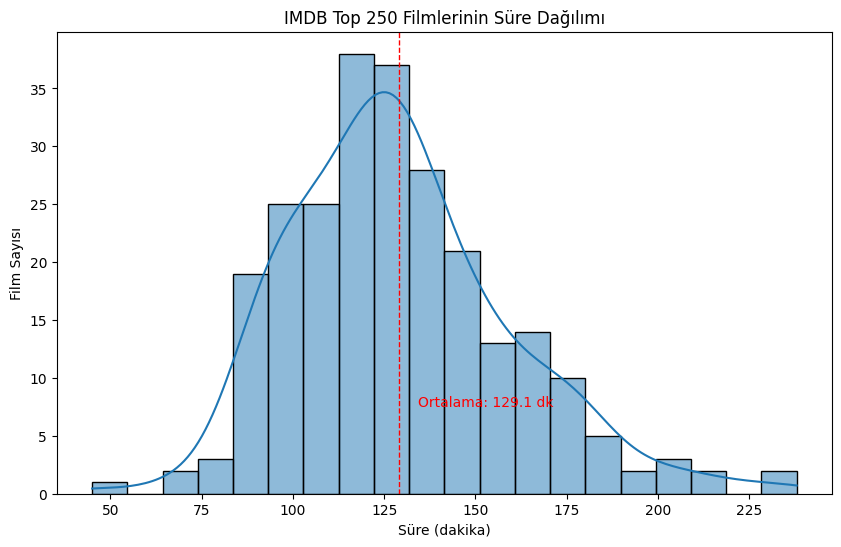

np.float64(129.132)

In [6]:

plt.figure(figsize=(10, 6))
sns.histplot(df['duration_minutes'], bins=20, kde=True)

plt.title('IMDB Top 250 Filmlerinin Süre Dağılımı')
plt.xlabel('Süre (dakika)')
plt.ylabel('Film Sayısı')

# Ortalama süreyi hesaplayıp grafiğe ekleme
mean_duration = df['duration_minutes'].mean()
plt.axvline(mean_duration, color='red', linestyle='dashed', linewidth=1)
plt.text(mean_duration + 5, df['duration_minutes'].count() * 0.03,
         f"Ortalama: {mean_duration:.1f} dk",
         color='red')

plt.show()

mean_duration


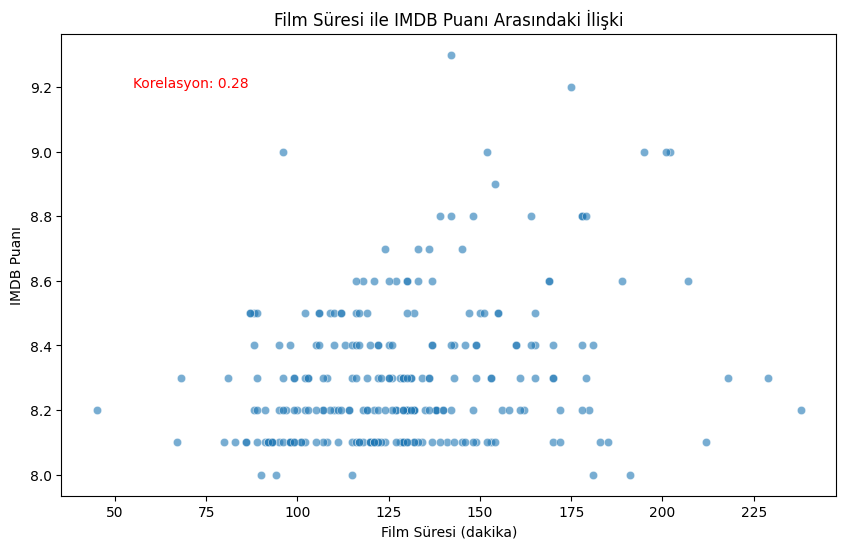

np.float64(0.27945970395472947)

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_minutes', y='imbd_rating', data=df, alpha=0.6)

plt.title('Film Süresi ile IMDB Puanı Arasındaki İlişki')
plt.xlabel('Film Süresi (dakika)')
plt.ylabel('IMDB Puanı')

# Korelasyon katsayısı
correlation = df['duration_minutes'].corr(df['imbd_rating'])

plt.text(df['duration_minutes'].min() + 10,
         df['imbd_rating'].max() - 0.1,
         f"Korelasyon: {correlation:.2f}",
         color='red')

plt.show()

correlation


In [8]:
director_counts = df['director_name'].value_counts()
director_counts.head(10)


,count
director_name,
Christopher Nolan,7
Steven Spielberg,7
Martin Scorsese,7
Akira Kurosawa,7
Stanley Kubrick,7
Alfred Hitchcock,6
Charles Chaplin,5
Quentin Tarantino,5
Billy Wilder,5


/tmp/ipython-input-2277779232.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_directors.values, y=top10_directors.index, palette="Blues_r")


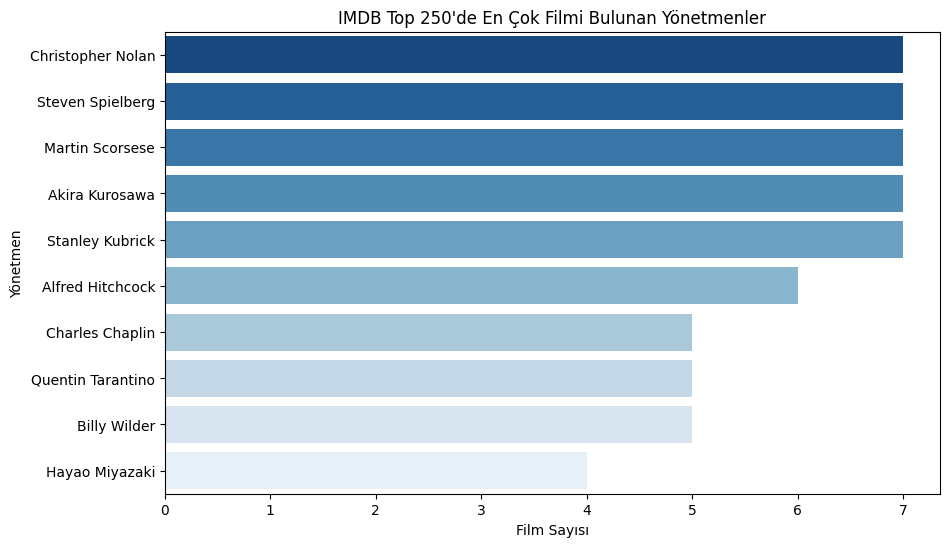

In [9]:
top10_directors = director_counts.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10_directors.values, y=top10_directors.index, palette="Blues_r")

plt.title("IMDB Top 250'de En Çok Filmi Bulunan Yönetmenler")
plt.xlabel("Film Sayısı")
plt.ylabel("Yönetmen")

plt.show()


In [10]:
# İlk 10 yönetmeni alıyoruz
top10_directors_list = top10_directors.index

# Bu yönetmenlerin filmlerini filtreleyelim
filtered_df = df[df['director_name'].isin(top10_directors_list)]

# Yönetmenlere göre ortalama IMDB puanı
avg_ratings = filtered_df.groupby('director_name')['imbd_rating'].mean().sort_values(ascending=False)

avg_ratings


,imbd_rating
director_name,
Christopher Nolan,8.557143
Quentin Tarantino,8.420000
Steven Spielberg,8.371429
Charles Chaplin,8.360000
Billy Wilder,8.320000
Alfred Hitchcock,8.316667
Stanley Kubrick,8.314286
Martin Scorsese,8.314286
Hayao Miyazaki,8.300000


/tmp/ipython-input-4197370146.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


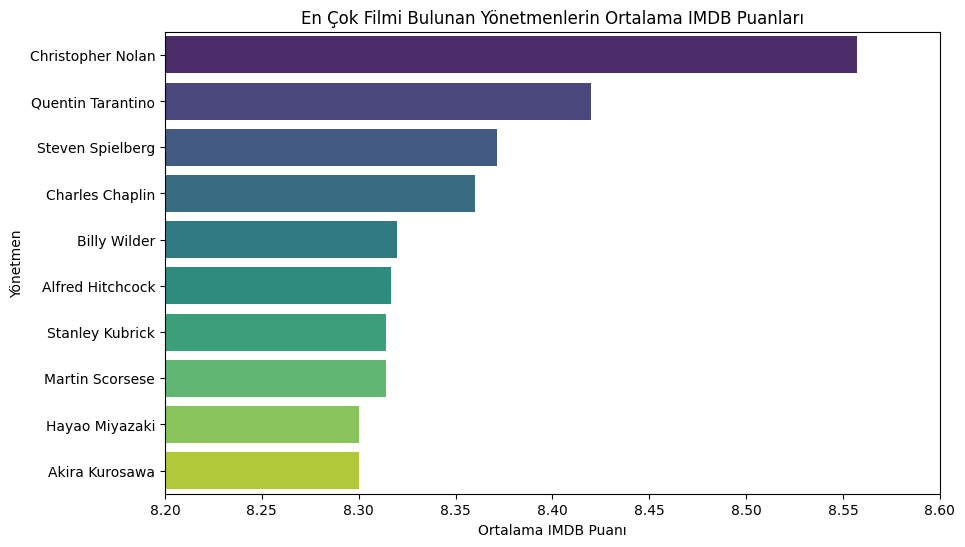

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=avg_ratings.values,
    y=avg_ratings.index,
    palette="viridis"
)

plt.title("En Çok Filmi Bulunan Yönetmenlerin Ortalama IMDB Puanları")
plt.xlabel("Ortalama IMDB Puanı")
plt.ylabel("Yönetmen")

plt.xlim(8.2, 8.6)  # değerleri daha net görmek için aralık daraltıyoruz

plt.show()


In [12]:
# Türleri virgülden ayırıp liste haline getirelim
df['genre_list'] = df['genre'].apply(lambda x: x.split(','))

# Her tür için ayrı satır oluşturma
df_genres = df.explode('genre_list')

# Temiz isim olsun diye kolon adını değiştiriyoruz
df_genres = df_genres.rename(columns={'genre_list': 'genre_single'})

df_genres[['title', 'genre', 'genre_single']].head(10)


,title,genre,genre_single
0,The Shawshank Redemption,Drama,Drama
1,The Godfather,"Crime,Drama",Crime
1,The Godfather,"Crime,Drama",Drama
2,The Dark Knight,"Action,Crime,Drama",Action
2,The Dark Knight,"Action,Crime,Drama",Crime
2,The Dark Knight,"Action,Crime,Drama",Drama
3,The Godfather Part II,"Crime,Drama",Crime
3,The Godfather Part II,"Crime,Drama",Drama
4,12 Angry Men,"Crime,Drama",Crime
4,12 Angry Men,"Crime,Drama",Drama


In [13]:
genre_stats = df_genres.groupby('genre_single').agg(
    film_sayisi = ('title', 'count'),
    ortalama_puan = ('imbd_rating', 'mean')
).sort_values(by="ortalama_puan", ascending=False)

genre_stats


,film_sayisi,ortalama_puan
genre_single,,
Music,4,8.400000
Crime,51,8.360784
Sci-Fi,20,8.360000
Action,50,8.348000
Horror,5,8.340000
Western,7,8.328571
Mystery,31,8.325806
Drama,177,8.320339
Fantasy,14,8.307143


/tmp/ipython-input-2003867186.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


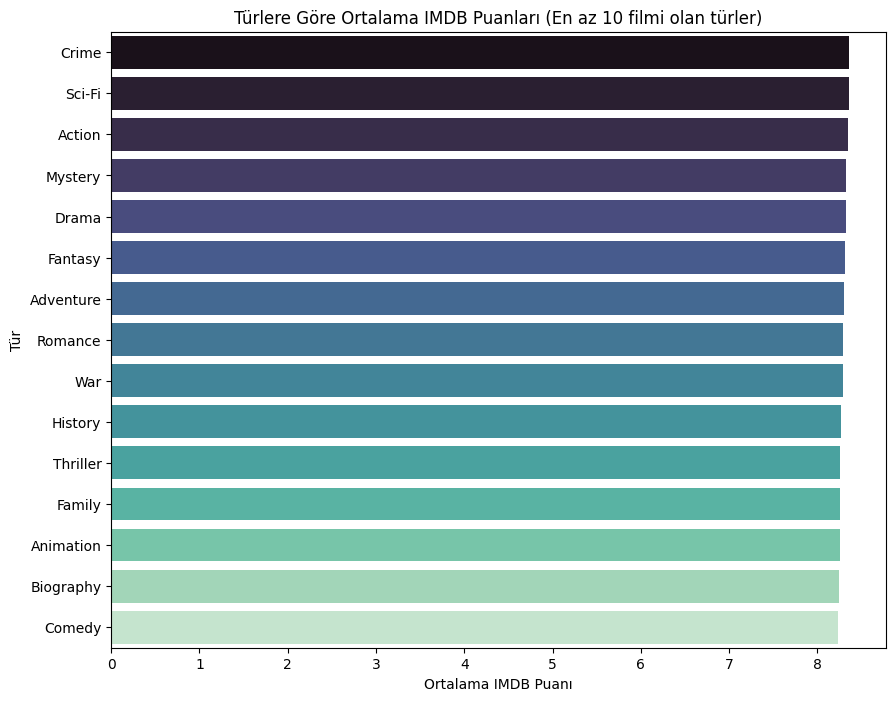

In [14]:
# Görselleştirmede en az 10 filmi olan türleri filtremek daha mantıklı
genre_filtered = genre_stats[genre_stats['film_sayisi'] >= 10]

plt.figure(figsize=(10, 8))
sns.barplot(
    x=genre_filtered['ortalama_puan'],
    y=genre_filtered.index,
    palette="mako"
)

plt.title("Türlere Göre Ortalama IMDB Puanları (En az 10 filmi olan türler)")
plt.xlabel("Ortalama IMDB Puanı")
plt.ylabel("Tür")

plt.show()
